In [127]:
RETRAIN_XGB = False

In [98]:
## imports for XGBoost multi-class classification
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight
import os

sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (10, 5)

np.random.seed(42)

## loading preprocessed data (from notebook 02) + reconstruction errors (from notebook 03)
X_train = np.load('../data/processed/X_train.npy')
X_test  = np.load('../data/processed/X_test.npy')
y_train = np.load('../data/processed/y_train.npy')
y_test  = np.load('../data/processed/y_test.npy')

recon_error_train = np.load('../data/processed/recon_error_train.npy')
recon_error_test  = np.load('../data/processed/recon_error_test.npy')

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"recon_error_train: {recon_error_train.shape}, recon_error_test: {recon_error_test.shape}")

label_map = {0: 'Normal', 1: 'DoS', 2: 'Probe', 3: 'R2L', 4: 'U2R'}
print("\nClass distribution (train):")
for cid, cname in label_map.items():
    print(f"  {cname:8s}: {(y_train == cid).sum()}")

X_train: (125973, 122), X_test: (22251, 122)
recon_error_train: (125973,), recon_error_test: (22251,)

Class distribution (train):
  Normal  : 67343
  DoS     : 45927
  Probe   : 11656
  R2L     : 995
  U2R     : 52


In [99]:
## building both feature sets for the ablation study
# Version A — baseline: 122 features only, no autoencoder signal
X_train_A = X_train
X_test_A  = X_test

# Version B — hybrid: 123 features, recon error injected as the last column
# reshape recon_error from (n,) to (n,1) so it can be hstacked as a column
X_train_B = np.hstack([X_train, recon_error_train.reshape(-1, 1)])
X_test_B  = np.hstack([X_test, recon_error_test.reshape(-1, 1)])

print(f"Version A (baseline) — X_train_A: {X_train_A.shape}, X_test_A: {X_test_A.shape}")
print(f"Version B (hybrid)   — X_train_B: {X_train_B.shape}, X_test_B: {X_test_B.shape}")

# sanity check: last column of Version B should exactly equal recon_error_train
assert np.allclose(X_train_B[:, -1], recon_error_train), "Injection mismatch!"
print("\nSanity check passed: last column of X_train_B matches recon_error_train")

Version A (baseline) — X_train_A: (125973, 122), X_test_A: (22251, 122)
Version B (hybrid)   — X_train_B: (125973, 123), X_test_B: (22251, 123)

Sanity check passed: last column of X_train_B matches recon_error_train


In [100]:
def error_summary_by_class(recon_error, y, dataset_name):
    label_map = {0: 'Normal', 1: 'DoS', 2: 'Probe', 3: 'R2L', 4: 'U2R'}
    print(f"--- {dataset_name} ---")
    for class_id, class_name in label_map.items():
        mask = (y == class_id)
        errs = recon_error[mask]
        print(f"{class_name:8s} (n={mask.sum():6d}): mean={errs.mean():.6f}, median={np.median(errs):.6f}")
    print()

# the content-only arrays you already saved
recon_error_content_train = np.load('../data/processed/recon_error_content_train.npy')
recon_error_content_test  = np.load('../data/processed/recon_error_content_test.npy')

error_summary_by_class(recon_error_content_train, y_train, "TRAIN — content-only error")
error_summary_by_class(recon_error_content_test,  y_test,  "TEST — content-only error")

# quick side-by-side: does content-only separate R2L/U2R from Normal
# better than the full-feature aggregate did?
recon_error_train = np.load('../data/processed/recon_error_train.npy')
recon_error_test  = np.load('../data/processed/recon_error_test.npy')

for cls in [3, 4]:  # R2L, U2R
    name = {3: 'R2L', 4: 'U2R'}[cls]
    normal_mean_full    = recon_error_test[y_test == 0].mean()
    normal_mean_content = recon_error_content_test[y_test == 0].mean()
    cls_mean_full    = recon_error_test[y_test == cls].mean()
    cls_mean_content = recon_error_content_test[y_test == cls].mean()
    print(f"{name}: full-feature ratio={cls_mean_full/normal_mean_full:.2f}x, "
          f"content-only ratio={cls_mean_content/normal_mean_content:.2f}x")

--- TRAIN — content-only error ---
Normal   (n= 67343): mean=0.004127, median=0.000000
DoS      (n= 45927): mean=0.060319, median=0.076901
Probe    (n= 11656): mean=0.034883, median=0.000000
R2L      (n=   995): mean=0.007979, median=0.000000
U2R      (n=    52): mean=0.042750, median=0.040043

--- TEST — content-only error ---
Normal   (n=  9711): mean=0.000940, median=0.000000
DoS      (n=  7167): mean=0.050804, median=0.076919
Probe    (n=  2421): mean=0.044925, median=0.076923
R2L      (n=  2885): mean=0.006287, median=0.000011
U2R      (n=    67): mean=0.050944, median=0.019410

R2L: full-feature ratio=3.60x, content-only ratio=6.69x
U2R: full-feature ratio=4.20x, content-only ratio=54.20x


In [101]:
recon_error_other_train = np.load('../data/processed/recon_error_other_train.npy')
recon_error_other_test  = np.load('../data/processed/recon_error_other_test.npy')

error_summary_by_class(recon_error_other_train, y_train, "TRAIN — non-content (traffic+basic) error")
error_summary_by_class(recon_error_other_test,  y_test,  "TEST — non-content (traffic+basic) error")

for cls in [1, 2]:  # DoS, Probe
    name = {1: 'DoS', 2: 'Probe'}[cls]
    normal_mean = recon_error_other_test[y_test == 0].mean()
    cls_mean    = recon_error_other_test[y_test == cls].mean()
    print(f"{name}: non-content ratio={cls_mean/normal_mean:.2f}x")

--- TRAIN — non-content (traffic+basic) error ---
Normal   (n= 67343): mean=0.001232, median=0.000046
DoS      (n= 45927): mean=0.046729, median=0.047502
Probe    (n= 11656): mean=0.035346, median=0.030141
R2L      (n=   995): mean=0.002247, median=0.000337
U2R      (n=    52): mean=0.008195, median=0.008490

--- TEST — non-content (traffic+basic) error ---
Normal   (n=  9711): mean=0.002470, median=0.000035
DoS      (n=  7167): mean=0.037001, median=0.039907
Probe    (n=  2421): mean=0.039956, median=0.038773
R2L      (n=  2885): mean=0.008545, median=0.009191
U2R      (n=    67): mean=0.004765, median=0.001103

DoS: non-content ratio=14.98x
Probe: non-content ratio=16.17x


In [102]:
## computing sample weights to counter severe class imbalance
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

print("Sample weight per class (should be higher for rarer classes):")
for cid, cname in label_map.items():
    w = sample_weights[y_train == cid][0]  # weight is identical within a class
    print(f"  {cname:8s} (n={int((y_train==cid).sum()):6d}): weight = {w:.4f}")

print(f"\nsample_weights shape: {sample_weights.shape}")
print(f"Ratio of U2R weight to Normal weight: {sample_weights[y_train==4][0] / sample_weights[y_train==0][0]:.1f}x")

Sample weight per class (should be higher for rarer classes):
  Normal   (n= 67343): weight = 0.3741
  DoS      (n= 45927): weight = 0.5486
  Probe    (n= 11656): weight = 2.1615
  R2L      (n=   995): weight = 25.3212
  U2R      (n=    52): weight = 484.5115

sample_weights shape: (125973,)
Ratio of U2R weight to Normal weight: 1295.1x


In [103]:
## Version A — baseline XGBoost, 122 features (no reconstruction error)
xgb_A = XGBClassifier(
    objective='multi:softmax',
    num_class=5,
    eval_metric='mlogloss',
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_A.fit(X_train_A, y_train, sample_weight=sample_weights)

## evaluate on test set
y_pred_A = xgb_A.predict(X_test_A)
f1_macro_A = f1_score(y_test, y_pred_A, average='macro')

print(f"Version A (baseline, 122 features) — Macro F1: {f1_macro_A:.4f}\n")
print(classification_report(y_test, y_pred_A, target_names=list(label_map.values())))

Version A (baseline, 122 features) — Macro F1: 0.6043

              precision    recall  f1-score   support

      Normal       0.71      0.97      0.82      9711
         DoS       0.97      0.87      0.91      7167
       Probe       0.81      0.73      0.77      2421
         R2L       0.97      0.09      0.16      2885
         U2R       0.70      0.24      0.36        67

    accuracy                           0.80     22251
   macro avg       0.83      0.58      0.60     22251
weighted avg       0.84      0.80      0.76     22251



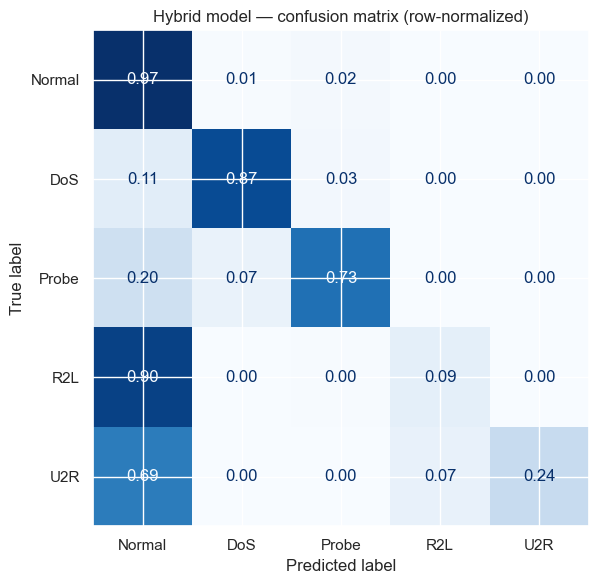

        Normal   DoS  Probe  R2L  U2R
Normal    9442    58    207    2    2
DoS        762  6220    185    0    0
Probe      487   165   1768    1    0
R2L       2609     0     14  257    5
U2R         46     0      0    5   16


In [104]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

class_names = list(label_map.values())

# normalized by true class (rows sum to 1) — shows where each class's errors land
cm_norm = confusion_matrix(y_test,y_pred_A, normalize='true')

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues', values_format='.2f', colorbar=False)
plt.title("Hybrid model — confusion matrix (row-normalized)")
plt.tight_layout()
plt.show()

# also print raw counts — useful for exact numbers in your writeup
cm_raw = confusion_matrix(y_test, y_pred_A)
print(pd.DataFrame(cm_raw, index=class_names, columns=class_names))

In [105]:
recon_error_content_train = np.load('../data/processed/recon_error_content_train.npy')
recon_error_content_test  = np.load('../data/processed/recon_error_content_test.npy')

X_train_hybrid = np.hstack([
    X_train,
    recon_error_content_train.reshape(-1, 1),
    recon_error_other_train.reshape(-1, 1),
])
X_test_hybrid = np.hstack([
    X_test,
    recon_error_content_test.reshape(-1, 1),
    recon_error_other_test.reshape(-1, 1),
])
print(f"Hybrid shape: {X_train_hybrid.shape}")   # (125973, 124)
print(f"Baseline shape: {X_train.shape}")         # (125973, 122)

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

xgb_hybrid = XGBClassifier(
    objective='multi:softprob', num_class=5,
    n_estimators=200, max_depth=8, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1
)
xgb_hybrid.fit(X_train_hybrid, y_train, sample_weight=sample_weights)

y_pred_hybrid = xgb_hybrid.predict(X_test_hybrid)
print(f"\nHybrid (content+non-content) macro F1: {f1_score(y_test, y_pred_hybrid, average='macro'):.4f}\n")
print(classification_report(y_test, y_pred_hybrid, target_names=list(label_map.values())))

Hybrid shape: (125973, 124)
Baseline shape: (125973, 122)

Hybrid (content+non-content) macro F1: 0.6355

              precision    recall  f1-score   support

      Normal       0.74      0.95      0.83      9711
         DoS       0.93      0.89      0.91      7167
       Probe       0.80      0.87      0.83      2421
         R2L       0.98      0.13      0.22      2885
         U2R       0.64      0.27      0.38        67

    accuracy                           0.81     22251
   macro avg       0.82      0.62      0.64     22251
weighted avg       0.84      0.81      0.78     22251



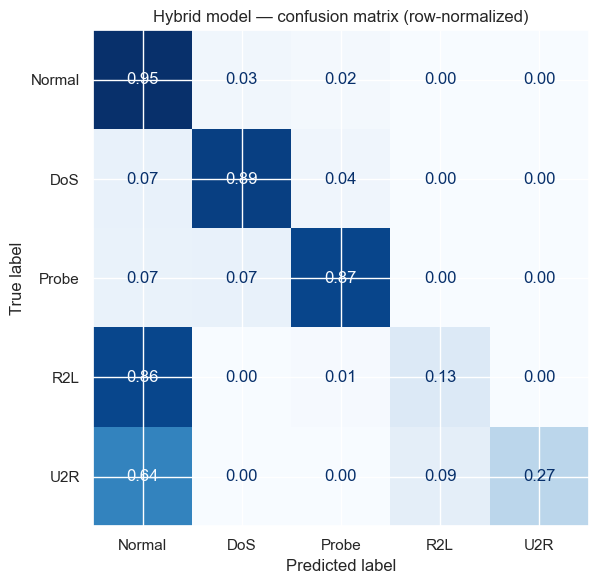

        Normal   DoS  Probe  R2L  U2R
Normal    9193   305    208    1    4
DoS        518  6369    280    0    0
Probe      159   167   2095    0    0
R2L       2488     1     24  366    6
U2R         43     0      0    6   18


In [106]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

class_names = list(label_map.values())

# normalized by true class (rows sum to 1) — shows where each class's errors land
cm_norm = confusion_matrix(y_test, y_pred_hybrid, normalize='true')

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues', values_format='.2f', colorbar=False)
plt.title("Hybrid model — confusion matrix (row-normalized)")
plt.tight_layout()
plt.show()

# also print raw counts — useful for exact numbers in your writeup
cm_raw = confusion_matrix(y_test, y_pred_hybrid)
print(pd.DataFrame(cm_raw, index=class_names, columns=class_names))

In [107]:
def bootstrap_per_class_diff(y_true, y_pred_baseline, y_pred_hybrid,
                              label_map, n_bootstrap=1000, random_state=42):
    rng = np.random.RandomState(random_state)
    n = len(y_true)
    y_true = np.asarray(y_true)
    y_pred_baseline = np.asarray(y_pred_baseline)
    y_pred_hybrid = np.asarray(y_pred_hybrid)

    class_ids = list(label_map.keys())
    diffs = {cid: np.empty(n_bootstrap) for cid in class_ids}
    macro_diffs = np.empty(n_bootstrap)

    for i in range(n_bootstrap):
        idx = rng.randint(0, n, n)
        f1_base   = f1_score(y_true[idx], y_pred_baseline[idx], average=None, labels=class_ids, zero_division=0)
        f1_hybrid = f1_score(y_true[idx], y_pred_hybrid[idx],   average=None, labels=class_ids, zero_division=0)
        for j, cid in enumerate(class_ids):
            diffs[cid][i] = f1_hybrid[j] - f1_base[j]
        macro_diffs[i] = f1_hybrid.mean() - f1_base.mean()

    print("Per-class F1 difference (hybrid - baseline), 95% CI:\n")
    for cid in class_ids:
        d = diffs[cid]
        lo, hi = np.percentile(d, [2.5, 97.5])
        verdict = "significant" if (lo > 0 or hi < 0) else "within noise"
        print(f"  {label_map[cid]:8s}: mean={d.mean():+.4f}  CI=[{lo:+.4f}, {hi:+.4f}]  -> {verdict}")

    lo, hi = np.percentile(macro_diffs, [2.5, 97.5])
    verdict = "significant" if (lo > 0 or hi < 0) else "within noise"
    print(f"\n  {'Macro F1':8s}: mean={macro_diffs.mean():+.4f}  CI=[{lo:+.4f}, {hi:+.4f}]  -> {verdict}")

    return diffs, macro_diffs

label_map = {0: 'Normal', 1: 'DoS', 2: 'Probe', 3: 'R2L', 4: 'U2R'}
diffs, macro_diffs = bootstrap_per_class_diff(y_test, y_pred_A, y_pred_hybrid, label_map)

Per-class F1 difference (hybrid - baseline), 95% CI:

  Normal  : mean=+0.0125  CI=[+0.0099, +0.0151]  -> significant
  DoS     : mean=-0.0047  CI=[-0.0075, -0.0018]  -> significant
  Probe   : mean=+0.0638  CI=[+0.0541, +0.0731]  -> significant
  R2L     : mean=+0.0618  CI=[+0.0491, +0.0757]  -> significant
  U2R     : mean=+0.0235  CI=[-0.0474, +0.0962]  -> within noise

  Macro F1: mean=+0.0314  CI=[+0.0166, +0.0464]  -> significant


In [108]:
diffs, macro_diffs = bootstrap_per_class_diff(
    y_test, y_pred_A, y_pred_hybrid, label_map, n_bootstrap=5000
)

Per-class F1 difference (hybrid - baseline), 95% CI:

  Normal  : mean=+0.0125  CI=[+0.0099, +0.0150]  -> significant
  DoS     : mean=-0.0048  CI=[-0.0076, -0.0018]  -> significant
  Probe   : mean=+0.0638  CI=[+0.0545, +0.0739]  -> significant
  R2L     : mean=+0.0616  CI=[+0.0490, +0.0746]  -> significant
  U2R     : mean=+0.0234  CI=[-0.0463, +0.0970]  -> within noise

  Macro F1: mean=+0.0313  CI=[+0.0170, +0.0464]  -> significant


### --------------------------------------------------------------------------------------------------------------------------


In [109]:
score_train = np.load("../data/preprocessed/behavioral_gaussian_score_train.npy")
score_test  = np.load("../data/preprocessed/behavioral_gaussian_score_test.npy")

In [110]:
X_train_125 = np.hstack([X_train_hybrid, score_train.reshape(-1, 1)])
X_test_125  = np.hstack([X_test_hybrid, score_test.reshape(-1, 1)])
assert X_train_125.shape[1] == X_train_hybrid.shape[1] + 1
print("125-feature matrix:", X_train_125.shape, X_test_125.shape)

125-feature matrix: (125973, 125) (22251, 125)


In [128]:
# Cell — fresh sample_weight, freshly retrain BOTH models (124 baseline + 125), same fixed params
from sklearn.utils.class_weight import compute_sample_weight
import xgboost as xgb
from sklearn.metrics import f1_score

sample_weight = compute_sample_weight(class_weight="balanced", y=y_train)

FIXED_PARAMS = dict(n_estimators=200, max_depth=8, learning_rate=0.1,   # match your shipped max_depth
                     subsample=0.8, colsample_bytree=0.8, random_state=42,
                     objective="multi:softprob", num_class=5, eval_metric="mlogloss", n_jobs=-1)

model_124 = xgb.XGBClassifier(**FIXED_PARAMS)
model_124.fit(X_train_hybrid, y_train, sample_weight=sample_weight)
pred_124 = model_124.predict(X_test_hybrid)
if RETRAIN_XGB:
    model_125 = XGBClassifier(**FIXED_PARAMS)
    model_125.fit(X_train_125, y_train, sample_weight=sample_weight)
else:
    model_125 = XGBClassifier()
    model_125.load_model("../models/xgboost_125_final.json")
    print("Loaded existing best XGBoost model — RETRAIN_XGB is False, no training happened")
pred_125 = model_125.predict(X_test_125)

print(f"124-feature macro F1: {f1_score(y_test, pred_124, average='macro'):.4f}")
print(f"125-feature macro F1: {f1_score(y_test, pred_125, average='macro'):.4f}")

Loaded existing best XGBoost model — RETRAIN_XGB is False, no training happened
124-feature macro F1: 0.6355
125-feature macro F1: 0.6407


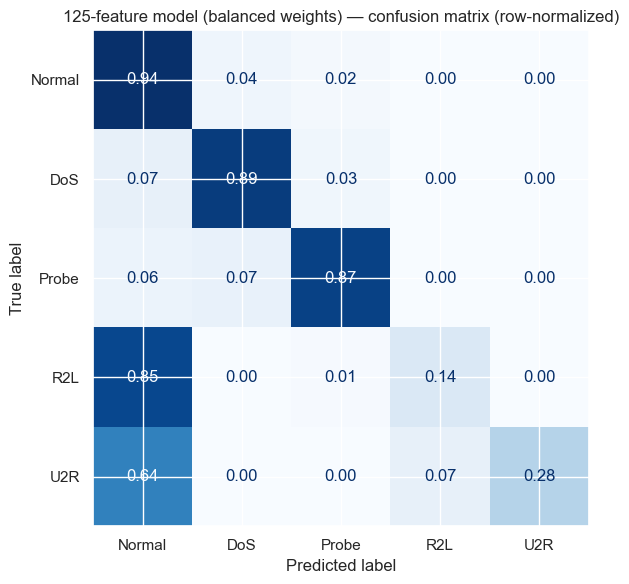

        Normal   DoS  Probe  R2L  U2R
Normal    9099   399    208    1    4
DoS        537  6383    247    0    0
Probe      141   166   2114    0    0
R2L       2458     1     23  395    8
U2R         43     0      0    5   19


In [112]:
class_names = list(label_map.values()) if isinstance(next(iter(label_map)), int) else list(label_map.keys())

cm_norm_125 = confusion_matrix(y_test, pred_125, normalize='true')
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm_125, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues', values_format='.2f', colorbar=False)
plt.title("125-feature model (balanced weights) — confusion matrix (row-normalized)")
plt.tight_layout()
plt.show()

cm_raw_125 = confusion_matrix(y_test, pred_125)
print(pd.DataFrame(cm_raw_125, index=class_names, columns=class_names))

In [113]:
# Cell — 5,000-sample bootstrap CI, per-class and macro (same methodology as your ratio/cascade rejections)
def bootstrap_f1_diff(y_true, pred_a, pred_b, n_boot=5000, seed=42):
    rng = np.random.RandomState(seed)
    n = len(y_true)
    classes = sorted(np.unique(y_true))
    diffs = {c: [] for c in classes}
    diffs["macro"] = []
    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        yt, pa, pb = y_true[idx], pred_a[idx], pred_b[idx]
        diffs["macro"].append(f1_score(yt, pb, average="macro", labels=classes, zero_division=0)
                               - f1_score(yt, pa, average="macro", labels=classes, zero_division=0))
        f1_a = f1_score(yt, pa, average=None, labels=classes, zero_division=0)
        f1_b = f1_score(yt, pb, average=None, labels=classes, zero_division=0)
        for c, da, db in zip(classes, f1_a, f1_b):
            diffs[c].append(db - da)
    results = {}
    for key, vals in diffs.items():
        vals = np.array(vals)
        lo, hi = np.percentile(vals, [2.5, 97.5])
        results[key] = (vals.mean(), lo, hi)
    return results

results = bootstrap_f1_diff(y_test, pred_124, pred_125)
class_names = {0: "Normal", 1: "DoS", 2: "Probe", 3: "R2L", 4: "U2R", "macro": "Macro F1"}
print(f"{'Class':10s} {'mean diff':>10s} {'95% CI':>20s}  verdict")
for key, (mean_diff, lo, hi) in results.items():
    verdict = "real INCREASE" if lo > 0 else "real DECREASE" if hi < 0 else "within noise"
    print(f"{class_names[key]:10s} {mean_diff:>+10.4f}  [{lo:+.4f}, {hi:+.4f}]  {verdict}")

Class       mean diff               95% CI  verdict
Normal        -0.0039  [-0.0052, -0.0026]  real DECREASE
DoS           -0.0049  [-0.0064, -0.0035]  real DECREASE
Probe         +0.0101  [+0.0069, +0.0134]  real INCREASE
R2L           +0.0157  [+0.0083, +0.0237]  real INCREASE
U2R           +0.0088  [-0.0174, +0.0498]  within noise
Macro F1      +0.0051  [-0.0005, +0.0137]  within noise


this is the difference between the hybrid with 124 features and hybrid with 125 features

In [114]:
# Cell — full-journey comparison: 125-feature (hybrid+behavioral) vs. ORIGINAL 122-feature stable baseline
# Adjust X_train_baseline / X_test_baseline to whatever you named the raw 122-feature arrays
model_baseline = xgb.XGBClassifier(**FIXED_PARAMS)
model_baseline.fit(X_train_A, y_train, sample_weight=sample_weight)
pred_baseline = model_baseline.predict(X_test_A)

print(f"122-feature baseline macro F1: {f1_score(y_test, pred_baseline, average='macro'):.4f}")
print(f"125-feature final macro F1:    {f1_score(y_test, pred_125, average='macro'):.4f}")

results_full = bootstrap_f1_diff(y_test, pred_baseline, pred_125)
print(f"\n{'Class':10s} {'mean diff':>10s} {'95% CI':>20s}  verdict")
for key, (mean_diff, lo, hi) in results_full.items():
    verdict = "real INCREASE" if lo > 0 else "real DECREASE" if hi < 0 else "within noise"
    print(f"{class_names[key]:10s} {mean_diff:>+10.4f}  [{lo:+.4f}, {hi:+.4f}]  {verdict}")

122-feature baseline macro F1: 0.6043
125-feature final macro F1:    0.6407

Class       mean diff               95% CI  verdict
Normal        +0.0086  [+0.0059, +0.0114]  real INCREASE
DoS           -0.0097  [-0.0128, -0.0065]  real DECREASE
Probe         +0.0739  [+0.0646, +0.0838]  real INCREASE
R2L           +0.0773  [+0.0639, +0.0909]  real INCREASE
U2R           +0.0321  [-0.0429, +0.1131]  within noise
Macro F1      +0.0365  [+0.0208, +0.0531]  real INCREASE


In [115]:
# Cell — CI-backed PERCENTAGE diff, bootstrapped directly (not scaled after the fact)
def bootstrap_f1_pct_diff(y_true, pred_a, pred_b, n_boot=5000, seed=42):
    rng = np.random.RandomState(seed)
    n = len(y_true)
    classes = sorted(np.unique(y_true))
    diffs = {c: [] for c in classes}
    diffs["macro"] = []
    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        yt, pa, pb = y_true[idx], pred_a[idx], pred_b[idx]

        f1_a_macro = f1_score(yt, pa, average="macro", labels=classes, zero_division=0)
        f1_b_macro = f1_score(yt, pb, average="macro", labels=classes, zero_division=0)
        if f1_a_macro > 0:
            diffs["macro"].append((f1_b_macro - f1_a_macro) / f1_a_macro * 100)

        f1_a = f1_score(yt, pa, average=None, labels=classes, zero_division=0)
        f1_b = f1_score(yt, pb, average=None, labels=classes, zero_division=0)
        for c, da, db in zip(classes, f1_a, f1_b):
            if da > 0:
                diffs[c].append((db - da) / da * 100)

    results = {}
    for key, vals in diffs.items():
        vals = np.array(vals)
        lo, hi = np.percentile(vals, [2.5, 97.5])
        results[key] = (vals.mean(), lo, hi)
    return results

results_pct = bootstrap_f1_pct_diff(y_test, pred_baseline, pred_125)
print(f"{'Class':10s} {'mean %':>10s} {'95% CI':>22s}  verdict")
for key, (mean_pct, lo, hi) in results_pct.items():
    verdict = "real INCREASE" if lo > 0 else "real DECREASE" if hi < 0 else "within noise"
    print(f"{class_names[key]:10s} {mean_pct:>+9.2f}%  [{lo:+6.2f}%, {hi:+6.2f}%]  {verdict}")

Class          mean %                 95% CI  verdict
Normal         +1.05%  [ +0.72%,  +1.39%]  real INCREASE
DoS            -1.06%  [ -1.40%,  -0.71%]  real DECREASE
Probe          +9.61%  [ +8.31%, +11.00%]  real INCREASE
R2L           +47.60%  [+37.35%, +58.89%]  real INCREASE
U2R           +10.35%  [-11.19%, +41.61%]  within noise
Macro F1       +6.05%  [ +3.40%,  +8.99%]  real INCREASE


In [129]:
# ===================================================================
# Best-of-runs tracker — fixed version
# ===================================================================
import os, json
import joblib
import pandas as pd
from sklearn.metrics import f1_score

BEST_RECORD_PATH = "../models/best_run_record.json"
MODEL_PATH = "../models/xgboost_125_final.json"
METADATA_PATH = "../models/xgboost_125_metadata.pkl"

current_macro_f1 = f1_score(y_test, pred_125, average='macro')

if os.path.exists(BEST_RECORD_PATH):
    with open(BEST_RECORD_PATH) as f:
        best_record = json.load(f)
    best_f1 = best_record["macro_f1"]
else:
    best_f1 = -1.0
    best_record = {}

best_f1_display = best_f1 if best_f1 >= 0 else 0.0   # compute this OUTSIDE the f-string

print(f"This run's macro F1: {current_macro_f1:.4f}")
print(f"Best so far:         {best_f1_display:.4f}" if best_f1 >= 0 else "No prior best recorded yet")

if current_macro_f1 > best_f1:
    model_125.save_model(MODEL_PATH)
    joblib.dump({"feature_count": 125, "params": FIXED_PARAMS}, METADATA_PATH)

    new_record = {
        "macro_f1": current_macro_f1,
        "timestamp": pd.Timestamp.now().isoformat(),
        "model_config": "125-feature hybrid, balanced sample_weight",
    }
    with open(BEST_RECORD_PATH, "w") as f:
        json.dump(new_record, f, indent=2)

    print(f"✅ NEW BEST — saved (macro F1 {current_macro_f1:.4f} > previous best {best_f1_display:.4f})")
else:
    print(f"⏭  Not an improvement ({current_macro_f1:.4f} <= {best_f1:.4f}) — "
          f"skipping save, existing model file untouched")

This run's macro F1: 0.6407
Best so far:         0.6407
⏭  Not an improvement (0.6407 <= 0.6407) — skipping save, existing model file untouched
